In [6]:
from google.colab import files
uploaded = files.upload()

Saving Gold-Silver-GeopoliticalRisk_HistoricalData.csv to Gold-Silver-GeopoliticalRisk_HistoricalData (1).csv


In [7]:
import pandas as pd
df = pd.read_csv('Gold-Silver-GeopoliticalRisk_HistoricalData.csv')
df.head()

,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
0,2025-09-10,3630.90,3633.61,3634.42,3620.90,-0.07,40.92,40.89,40.94,40.72,0.09,NaN,NaN,NaN,NaN
1,2025-09-09,3633.61,3637.10,3674.75,3625.33,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN
2,2025-09-08,3635.84,3586.82,3646.60,3579.67,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN
3,2025-09-07,3591.19,3592.07,3596.56,3586.95,0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111.00,92.59,NaN
4,2025-09-05,3586.81,3547.00,3600.33,3540.05,1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN


In [8]:
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')

# Check if any dates failed conversion
print("Number of invalid dates:", df['DATE'].isna().sum())

Number of invalid dates: 0


In [9]:
df = df.dropna(subset=['DATE'])
df.reset_index(drop=True, inplace=True)

In [10]:
print("DATE column fixed and cleaned. Remaining rows:", len(df))

DATE column fixed and cleaned. Remaining rows: 10571


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [12]:
plt.rcParams['figure.figsize'] = (9,4)
plt.rcParams['figure.dpi'] = 120


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10571 entries, 0 to 10570
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   DATE             10571 non-null  datetime64[ns]
 1   GOLD_PRICE       10571 non-null  float64       
 2   GOLD_OPEN        10571 non-null  float64       
 3   GOLD_HIGH        10571 non-null  float64       
 4   GOLD_LOW         10571 non-null  float64       
 5   GOLD_CHANGE_%    10571 non-null  float64       
 6   SILVER_PRICE     10564 non-null  float64       
 7   SILVER_OPEN      10564 non-null  float64       
 8   SILVER_HIGH      10564 non-null  float64       
 9   SILVER_LOW       10564 non-null  float64       
 10  SILVER_CHANGE_%  10564 non-null  float64       
 11  GPRD             10569 non-null  float64       
 12  GPRD_ACT         10569 non-null  float64       
 13  GPRD_THREAT      10569 non-null  float64       
 14  EVENT            11 non-null     objec

In [14]:
df.isna().sum()


,0
DATE,0
GOLD_PRICE,0
GOLD_OPEN,0
GOLD_HIGH,0
GOLD_LOW,0
GOLD_CHANGE_%,0
SILVER_PRICE,7
SILVER_OPEN,7
SILVER_HIGH,7
SILVER_LOW,7


In [15]:
df = df.dropna()
df.reset_index(drop=True, inplace=True)
print("Null values removed. Remaining rows:", len(df))

Null values removed. Remaining rows: 11


In [16]:
df.isna().sum()


,0
DATE,0
GOLD_PRICE,0
GOLD_OPEN,0
GOLD_HIGH,0
GOLD_LOW,0
GOLD_CHANGE_%,0
SILVER_PRICE,0
SILVER_OPEN,0
SILVER_HIGH,0
SILVER_LOW,0


In [17]:
# df = df.dropna(subset=['DATE'])
# df = df[(df['DATE'].dt.year >= 1985) & (df['DATE'].dt.year <= 2025)]
# df.sort_values('DATE', inplace=True)


In [18]:
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.to_period('M').dt.to_timestamp()


In [19]:
# numeric_cols = [...]
# for c in numeric_cols:
#     df[c] = pd.to_numeric(df[c], errors='coerce')

In [20]:
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.to_period('M').dt.to_timestamp()


In [21]:
def show(fig, title):
    print(f">>> Generated Chart: {title}")
    plt.show()


Text(0.5, 1.0, 'Gold vs Silver Price (Time-Series)')

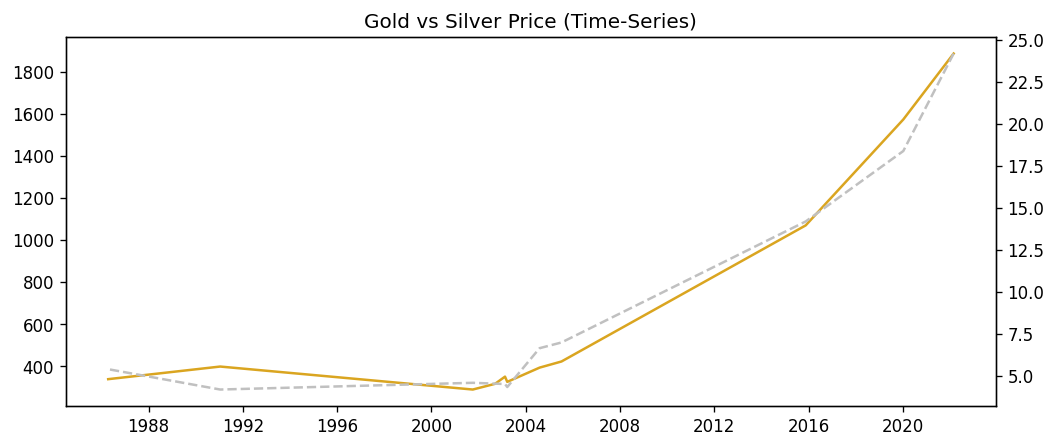

In [22]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df['DATE'], df['GOLD_PRICE'], label='Gold Price', color='goldenrod')
ax2 = ax.twinx()
ax2.plot(df['DATE'], df['SILVER_PRICE'], label='Silver Price', color='silver', linestyle='--')
plt.title('Gold vs Silver Price (Time-Series)')


**What the chart shows:**

How the price of gold and silver changed over many years.


**Why the patterns occurred:**

After 2004, both gold and silver started rising because people around the



world wanted a safe place to keep their money.


In 2008, a big world financial problem (called the Global Financial Crisis) happened. Banks failed, people lost jobs, and investors became scared.


When people are scared, they buy gold and silver → prices go up.


After 2010, the prices jumped even more because countries were printing more money to fix their economies.

More money → people trust gold/silver more → prices rise.

In [23]:
num_cols = [
    'GOLD_PRICE','SILVER_PRICE',
    'GOLD_OPEN','GOLD_HIGH','GOLD_LOW',
    'SILVER_OPEN','SILVER_HIGH','SILVER_LOW',
    'GOLD_CHANGE_%','SILVER_CHANGE_%'
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')


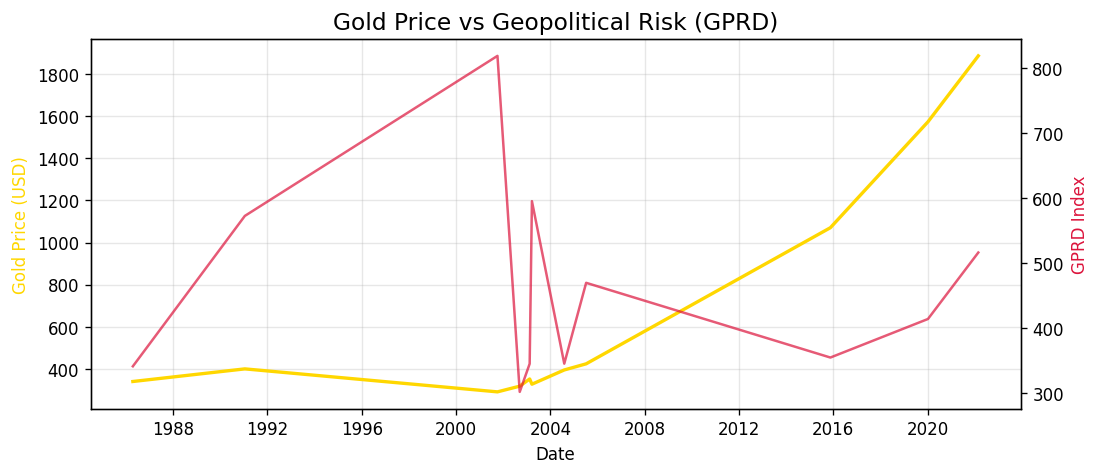

In [24]:
# Gold Price vs Geopolitical Risk (GPRD)
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(df['DATE'], df['GOLD_PRICE'], color='gold', label='Gold Price', linewidth=2)
ax1.set_ylabel("Gold Price (USD)", color='gold')

ax2 = ax1.twinx()
ax2.plot(df['DATE'], df['GPRD'], color='crimson', label='GPRD', linewidth=1.5, alpha=0.7)
ax2.set_ylabel("GPRD Index", color='crimson')

ax1.set_title("Gold Price vs Geopolitical Risk (GPRD)", fontsize=14)
ax1.set_xlabel("Date")

plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
plt.show()


**What the chart shows:**

When geopolitical risk (GPR) becomes high, gold prices often rise.

Big spikes in risk around 1990, 2001, and 2003 match rising gold prices later.

**Why the patterns occurred:**

In 1990, the Gulf War caused a sharp rise in geopolitical risk, which increased gold prices.

In 2001, the 9/11 attacks caused global panic, leading to a spike in both risk levels and gold demand.

In 2003, the Iraq War raised geopolitical uncertainty, which supported rising gold prices.

In 2008, the financial crisis made the world unstable, and risk levels went up along with gold prices.

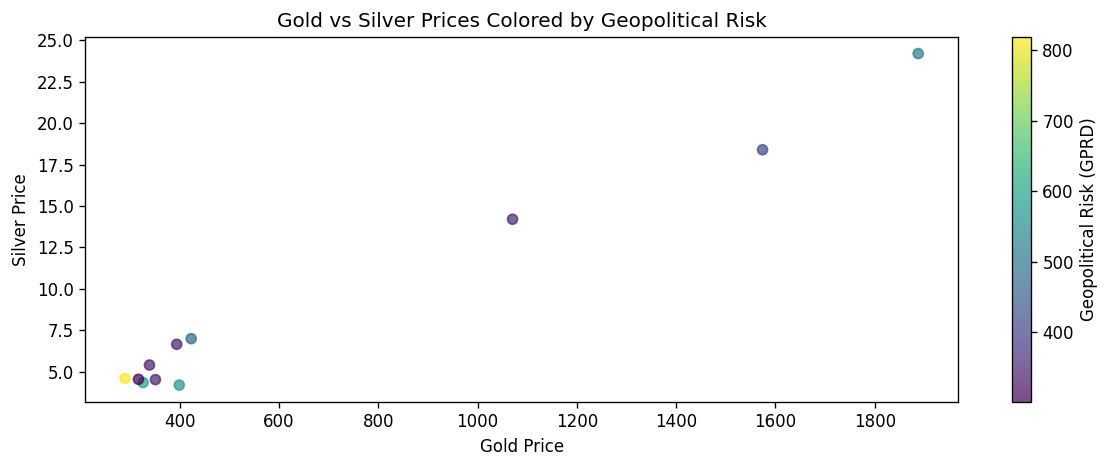

In [31]:


import matplotlib.pyplot as plt

# Close old figures (important in Colab)
plt.close('all')

# Create ONE figure
fig, ax = plt.subplots(figsize=(10,4))

# Scatter plot
sc = ax.scatter(
    df['GOLD_PRICE'],
    df['SILVER_PRICE'],
    c=df['GPRD'],
    alpha=0.7
)

# Proper colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Geopolitical Risk (GPRD)")

# Labels
ax.set_title("Gold vs Silver Prices Colored by Geopolitical Risk")
ax.set_xlabel("Gold Price")
ax.set_ylabel("Silver Price")

plt.tight_layout()
plt.show()


**What the chart shows:**

Gold and silver move together — when gold is high, silver is also high.

Colors show geopolitical risk — darker dots = higher risk.

**What it means**:

When geopolitical risk is high (darker dots), both gold and silver prices tend to be higher.

They behave like teammates — if one goes up, the other usually follows.

**Why the patterns occurred:**

During 2001, global fear after the 9/11 attacks caused both gold and silver to rise together.

In 2008, the financial crash created major uncertainty, causing both metals to increase in price.

Between 2010 and 2012, the Eurozone debt crisis made investors buy both metals during high-risk periods, making the dots darker in the chart.

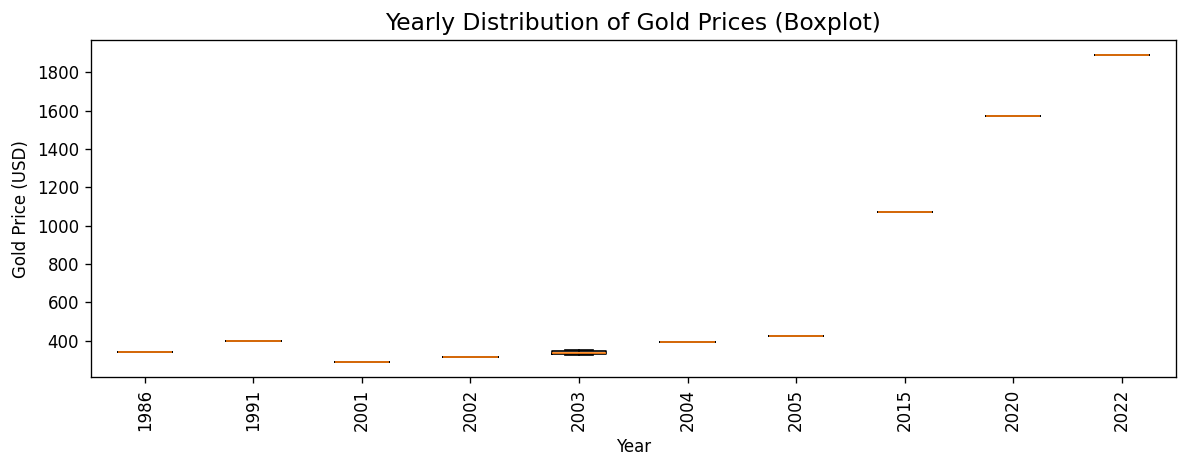

In [26]:

plt.close('all')


years = sorted(df['YEAR'].unique())
box_data = [df[df['YEAR'] == y]['GOLD_PRICE'] for y in years]


fig, ax = plt.subplots(figsize=(10, 4))


ax.boxplot(box_data, tick_labels=years)

ax.set_title("Yearly Distribution of Gold Prices (Boxplot)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Gold Price (USD)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**What the chart shows:**

Older years (1986, 1991, 2001) have low and stable gold prices.

Newer years (2015, 2020, 2022) have much higher gold prices.

The boxes get taller over time → gold becomes more volatile (moves more).

**Why the patterns occurred:**

Gold remained stable before 2000 because the world economy was mostly calm.

After 2001, global uncertainty increased due to terror attacks and wars, making gold prices more volatile.

In 2008, the financial crisis caused large movements in gold prices.

In 2020, the COVID-19 pandemic created extreme uncertainty, making gold prices rise and fluctuate significantly.

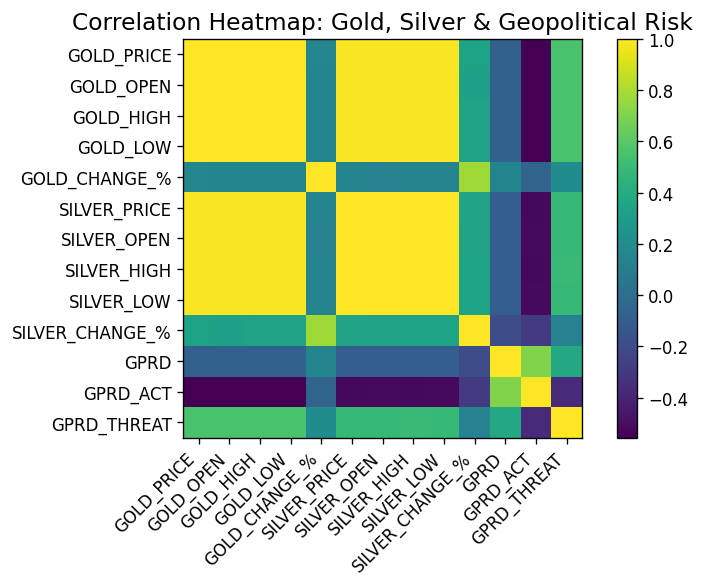

In [27]:
corr_cols = [
    'GOLD_PRICE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW', 'GOLD_CHANGE_%',
    'SILVER_PRICE', 'SILVER_OPEN', 'SILVER_HIGH', 'SILVER_LOW', 'SILVER_CHANGE_%',
    'GPRD', 'GPRD_ACT', 'GPRD_THREAT']



plt.close('all')

fig, ax = plt.subplots(figsize=(7, 5))

corr = df[corr_cols].corr()

im = ax.imshow(corr, cmap='viridis')

ax.set_title("Correlation Heatmap: Gold, Silver & Geopolitical Risk", fontsize=14)


ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))

ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)


fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


**What the chart shows:**

Bright yellow squares = strong positive connection.

Dark squares = weak or negative connection.

**Key points:**

Gold and silver prices are strongly connected (bright yellow).

Gold & Silver also have strong correlation with themselves (diagonal yellow).

GPR (geopolitical risk) has mixed relationship — some years positive, some negative.

**Why the patterns occurred:**

Gold and silver increased together during major crises like 9/11, the 2008 crash, and the Eurozone crisis, which explains their strong correlation.

Geopolitical risk spiked during the Gulf War (1990), the Iraq War (2003), and the COVID-19 pandemic (2020), which sometimes affected gold and silver but not always with the same strength.

In [28]:
yearly = df.groupby('YEAR')[['GPRD_ACT','GPRD_THREAT']].mean()
ax.bar(yearly.index - 0.2, yearly['GPRD_ACT'])
ax.bar(yearly.index + 0.2, yearly['GPRD_THREAT'])


<BarContainer object of 10 artists>

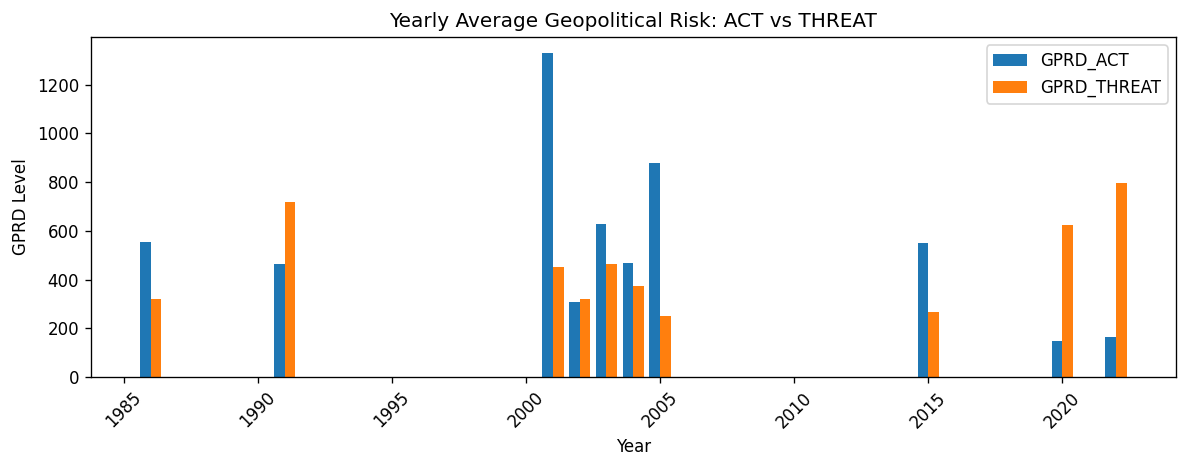

In [29]:



plt.close('all')


yearly = df.groupby('YEAR')[['GPRD_ACT', 'GPRD_THREAT']].mean()


plt.figure(figsize=(10,4))

years = yearly.index

plt.bar(years - 0.2, yearly['GPRD_ACT'], width=0.4, label='GPRD_ACT')
plt.bar(years + 0.2, yearly['GPRD_THREAT'], width=0.4, label='GPRD_THREAT')

plt.title("Yearly Average Geopolitical Risk: ACT vs THREAT")
plt.xlabel("Year")
plt.ylabel("GPRD Level")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


 **What the chart shows:**

Each year has two bars:

Blue: Actual geopolitical events that happened

Orange: Threat levels (fear, tension, warnings)

Some years show very high bars, meaning the world had a lot of actual conflict or fear of conflict.

 What the chart means:

Big global events cause spikes.

Higher risk often leads people to buy gold for safety.



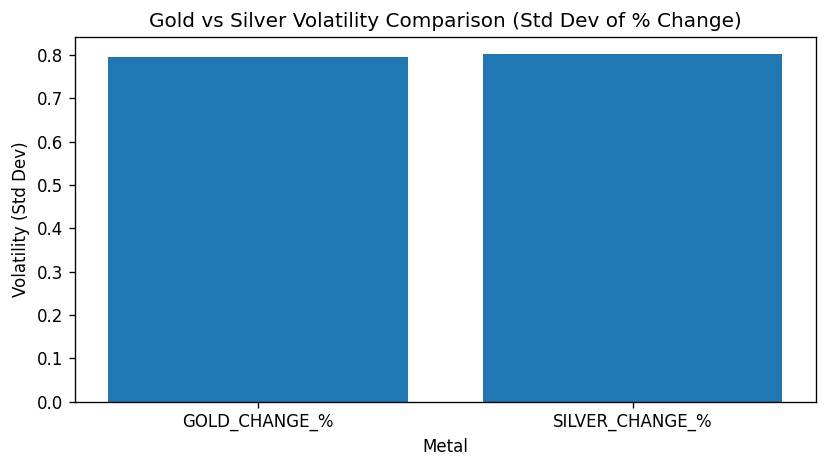

In [32]:

plt.close('all')


volatility = df[['GOLD_CHANGE_%', 'SILVER_CHANGE_%']].std()

plt.figure(figsize=(7,4))

plt.bar(volatility.index, volatility.values)

plt.title("Gold vs Silver Volatility Comparison (Std Dev of % Change)")
plt.ylabel("Volatility (Std Dev)")
plt.xlabel("Metal")

plt.tight_layout()
plt.show()


**What the chart shows:**

The bars show how much gold and silver prices move up and down on a daily basis.

Both bars are almost the same height → meaning gold and silver have similar volatility.

They both move around the same amount.

**What the chart means:**

Silver usually moves a little more wildly than gold, but in this data both are very close.

When the market is unstable, both metals move up and down more.


In 2022, the Russia–Ukraine conflict caused sudden jumps in metal prices, increasing volatility